In [ ]:
import optgraphstate as ogs
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from optimization_script import run_optimization
import stim
import igraph as ig
import scipy.io
import os
import pickle
import random
from optgraphstate import GraphState
#Load the functions for linear rank width 
from rank_width import linear_rank_width, lrw_of_ordering
# Load the functions for linear rank width SA
from rank_width_sa import linear_rank_width_sa
# Load the functions for path clustering
from path_clustering import path_clustering_lrw

In [4]:
# --- Define Egde reduction function ---
def edge_reduction_func(input_graph):
    our_graph_original = input_graph.copy()
    # Create a mapping dictionary: (0, 0) -> 0, (0, 1) -> 1, ..., (2, 2) -> 8
    mapping = {node: i for i, node in enumerate(our_graph_original.nodes())}

    # Create a new graph with integer labels
    our_graph = nx.relabel_nodes(our_graph_original, mapping)
    graph , circ, statistics = run_optimization(our_graph, edge_reduction=True, minLA=False, opt_CNOT= False)
    return graph

def local_complementation(input_graph: nx.Graph, node):
        """local complementations on networkx graph

        Arguments:
            input_graph -- graphs
            node -- target node for the local complementation

        Returns:
            the locally complemented networkx graph
        """
        graph = input_graph.copy()
        sub_graph = nx.ego_graph(graph, node, 1, center=False)
        lc_graph = nx.compose(graph, nx.complement(sub_graph))
        lc_graph.remove_edges_from(sub_graph.edges())
        return lc_graph

In [ ]:
# File saving and loading functions
def save_simulation_results(data, simulation_name, data_type, base_path='/Users/konstantinosrafailrevis/Desktop/PhD/photonic_state_generation/simulations_data', db_name='repeater_graph'):
    """
    Save simulation results to a text file.
    
    Args:
        data: List or array of numerical data to save
        simulation_name: Name of the simulation (e.g., 'SAminLA20', 'DP_edge_red')
        data_type: Type of data ('emitters' or 'cnots')
        base_path: Directory where files will be saved
        db_name: Prefix for the filename (default: 'repeater_graph')
    """
    filename = f'{base_path}/{db_name}_{data_type}_{simulation_name}.txt'
    np.savetxt(filename, data, fmt='%d')
    print(f"Saved {data_type} data to: {filename}")
    
def load_simulation_results(simulation_name, data_type, base_path='/Users/konstantinosrafailrevis/Desktop/PhD/photonic_state_generation/simulations_data', db_name='repeater_graph'):
    """
    Load simulation results from a text file.
    
    Args:
        simulation_name: Name of the simulation (e.g., 'SAminLA20')
        data_type: Type of data ('emitters' or 'cnots')
        base_path: Directory where files are stored
        db_name: Prefix for the filename (default: 'repeater_graph')
        
    Returns:
        Numpy array with the loaded data
    """
    filename = f'{base_path}/{db_name}_{data_type}_{simulation_name}.txt'
    data = np.loadtxt(filename, dtype=int)
    print(f"Loaded {data_type} data from: {filename}")
    return data

In [ ]:
# --- Create the database based on local complementations on circles of varying sizes ---
min_nodes = 6
max_nodes = 45
num_variants = 30  # number of LC-variant graphs per circle size
num_lc_steps_range = (5, 20)  # range of random LC operations per variant
seed = 42
random.seed(seed)
np.random.seed(seed)

# Output directory
db_path = os.path.join(os.getcwd(), 'circle_database')
os.makedirs(db_path, exist_ok=True)

# --- Generate the database ---
database = {}  # {n: [list of 30 nx.Graph objects]}

for n in range(min_nodes, max_nodes + 1):
    base_graph = nx.cycle_graph(n)
    variants = []
    
    for v in range(num_variants):
        g = base_graph.copy()
        # Apply a random number of local complementations
        num_lc = random.randint(*num_lc_steps_range)
        for _ in range(num_lc):
            node = random.choice(list(g.nodes()))
            g = local_complementation(g, node)
        variants.append(g)
    
    database[n] = variants
    print(f"Circle n={n}: generated {num_variants} LC-variants (nodes={n}, edges vary)")

# --- Save individual graphs as edge-lists (for reproducibility) ---
for n, variants in database.items():
    for v_idx, g in enumerate(variants):
        filepath = os.path.join(db_path, f'circle_n{n}_v{v_idx}.edgelist')
        nx.write_edgelist(g, filepath, data=False)

# --- Save the whole database as a pickle for easy reloading ---
pickle_path = os.path.join(db_path, 'circle_database.pkl')
with open(pickle_path, 'wb') as f:
    pickle.dump(database, f)

print(f"\nDatabase saved to: {db_path}")
print(f"  - {len(database)} graph sizes (n={min_nodes}..{max_nodes})")
print(f"  - {num_variants} variants each")
print(f"  - Total graphs: {len(database) * num_variants}")
print(f"  - Pickle file: {pickle_path}")
print(f"  - Edge-list files: circle_n<N>_v<V>.edgelist")

Circle n=6: generated 30 LC-variants (nodes=6, edges vary)
Circle n=7: generated 30 LC-variants (nodes=7, edges vary)
Circle n=8: generated 30 LC-variants (nodes=8, edges vary)
Circle n=9: generated 30 LC-variants (nodes=9, edges vary)
Circle n=10: generated 30 LC-variants (nodes=10, edges vary)
Circle n=11: generated 30 LC-variants (nodes=11, edges vary)
Circle n=12: generated 30 LC-variants (nodes=12, edges vary)
Circle n=13: generated 30 LC-variants (nodes=13, edges vary)
Circle n=14: generated 30 LC-variants (nodes=14, edges vary)
Circle n=15: generated 30 LC-variants (nodes=15, edges vary)
Circle n=16: generated 30 LC-variants (nodes=16, edges vary)
Circle n=17: generated 30 LC-variants (nodes=17, edges vary)
Circle n=18: generated 30 LC-variants (nodes=18, edges vary)
Circle n=19: generated 30 LC-variants (nodes=19, edges vary)
Circle n=13: generated 30 LC-variants (nodes=13, edges vary)
Circle n=14: generated 30 LC-variants (nodes=14, edges vary)
Circle n=15: generated 30 LC-var

In [71]:
# --- Load the database from pickle ---
import pickle

with open('circle_database/circle_database.pkl', 'rb') as f:
    loaded_db = pickle.load(f)

print(f"Loaded {len(loaded_db)} graph sizes (n={min(loaded_db)}..{max(loaded_db)})")
print(f"{len(loaded_db[6])} variants per size")
print(f"Total graphs: {sum(len(v) for v in loaded_db.values())}")

# Quick sanity check: each entry is an nx.Graph
sample = loaded_db[10][0]
print(f"\nSample graph (n=10, variant 0): {sample.number_of_nodes()} nodes, {sample.number_of_edges()} edges")
print(f"Type: {type(sample)}")

Loaded 40 graph sizes (n=6..45)
30 variants per size
Total graphs: 1200

Sample graph (n=10, variant 0): 10 nodes, 18 edges
Type: <class 'networkx.classes.graph.Graph'>


Graph n=10 variant 3: 10 nodes, 20 edges
Nodes: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]...
Edges: [(0, 2), (0, 4), (0, 3), (0, 9), (1, 2), (1, 4), (1, 3), (2, 9), (2, 3), (2, 4)]...


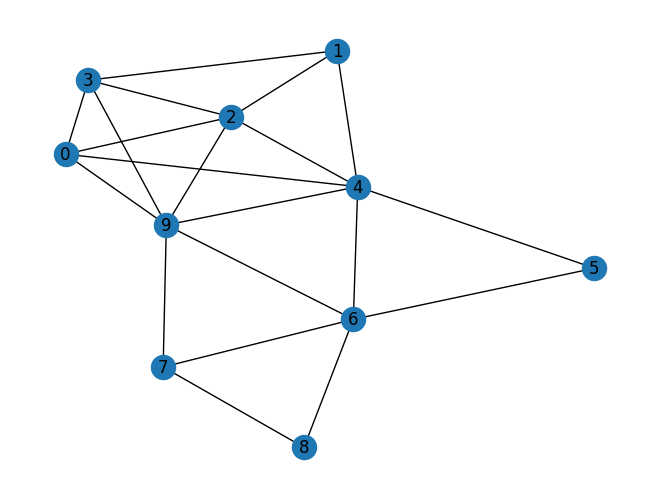

In [75]:
# --- Example: iterate over all graphs for analysis ---
# loaded_db is a dict: {n_nodes: [list of 30 nx.Graph objects]}

# Example: process every graph
for n_nodes, variants in loaded_db.items():
    for v_idx, graph in enumerate(variants):
        # graph is a standard nx.Graph — use it directly
        # e.g.: run_optimization(graph, ...), linear_rank_width(graph), etc.
        pass

# Example: get a single graph
graph_10_v3 = loaded_db[10][3]  # circle n=10, variant 3
print(f"Graph n=10 variant 3: {graph_10_v3.number_of_nodes()} nodes, {graph_10_v3.number_of_edges()} edges")
print(f"Nodes: {list(graph_10_v3.nodes())[:10]}...")
print(f"Edges: {list(graph_10_v3.edges())[:10]}...")
nx.draw(graph_10_v3, with_labels=True)

## rank_width

In [78]:
# --- Benchmark: linear_rank_width_sa on circle database ---
from collections import defaultdict

# Storage: {n_nodes: {'emitters': [...], 'cnots': [...]}}
results = defaultdict(lambda: {'emitters': [], 'cnots': []})

# Average and std storage
avg_emitters = []
std_emitters = []
avg_cnots = []
std_cnots = []
node_sizes = sorted(loaded_db.keys())

for n_nodes in node_sizes:
    variants = loaded_db[n_nodes]
    graph_emitters_rank_width_sa = []
    graph_cnots_rank_width_sa = []
    print(f"------------Processing n={n_nodes} with {len(variants)} variants...------------")
    for v_idx, G in enumerate(variants):
        print(f"  Variant {v_idx}")
        try:
            # Edge reduction
            G = edge_reduction_func(G)
            
            # Linear rank width ordering
            cost, final_ordering = linear_rank_width(G)
            print(f"n={n_nodes}, variant {v_idx}: ordering found (lrw={cost})")
            
            # Relabel and optimize
            ordered_graph = nx.relabel_nodes(G, {old: new for new, old in enumerate(final_ordering)})
            opt_graph, circuit, stats = run_optimization(ordered_graph, edge_reduction=False, minLA=False, opt_CNOT=True)
            
            graph_emitters_rank_width_sa.append(stats[0])
            graph_cnots_rank_width_sa.append(stats[1])
        except Exception as e:
            print(f"  ERROR n={n_nodes}, variant {v_idx}: {e}")
    
    # Store per-node results
    results[n_nodes]['emitters'] = graph_emitters_rank_width_sa
    results[n_nodes]['cnots'] = graph_cnots_rank_width_sa
    
    # Compute average and std
    avg_e = np.mean(graph_emitters_rank_width_sa)
    std_e = np.std(graph_emitters_rank_width_sa)
    avg_c = np.mean(graph_cnots_rank_width_sa)
    std_c = np.std(graph_cnots_rank_width_sa)
    
    avg_emitters.append(avg_e)
    std_emitters.append(std_e)
    avg_cnots.append(avg_c)
    std_cnots.append(std_c)
    
    print(f"  n={n_nodes}: emitters={avg_e:.2f}±{std_e:.2f}, cnots={avg_c:.2f}±{std_c:.2f}\n")

# --- Save results ---
# Save averages
save_simulation_results(avg_emitters, 'circle_db_rank_width_avg', 'emitters')
save_simulation_results(avg_cnots, 'circle_db_rank_width_avg', 'cnots')

# Save std deviations
save_simulation_results(std_emitters, 'circle_db_rank_width_std', 'emitters')
save_simulation_results(std_cnots, 'circle_db_rank_width_std', 'cnots')

# Save raw per-variant results (all 30 values per node size) as a 2D array
all_emitters = np.array([results[n]['emitters'] for n in node_sizes])
all_cnots = np.array([results[n]['cnots'] for n in node_sizes])
save_simulation_results(all_emitters, 'circle_db_rank_width_raw', 'emitters')
save_simulation_results(all_cnots, 'circle_db_rank_width_raw', 'cnots')

# Save node sizes for reference
save_simulation_results(node_sizes, 'circle_db_rank_width', 'node_sizes')
print(f"\nDone! Processed {len(node_sizes)} graph sizes times {len(variants)} variants = {len(node_sizes)*len(variants)} graphs")

------------Processing n=6 with 30 variants...------------
  Variant 0
n=6, variant 0: ordering found (lrw=2)
  Variant 1
n=6, variant 1: ordering found (lrw=2)
  Variant 2
n=6, variant 2: ordering found (lrw=2)
  Variant 3
n=6, variant 3: ordering found (lrw=2)
  Variant 4
n=6, variant 2: ordering found (lrw=2)
  Variant 3
n=6, variant 3: ordering found (lrw=2)
  Variant 4
n=6, variant 4: ordering found (lrw=2)
  Variant 5
n=6, variant 5: ordering found (lrw=2)
  Variant 6
n=6, variant 6: ordering found (lrw=2)
  Variant 7
n=6, variant 4: ordering found (lrw=2)
  Variant 5
n=6, variant 5: ordering found (lrw=2)
  Variant 6
n=6, variant 6: ordering found (lrw=2)
  Variant 7
n=6, variant 7: ordering found (lrw=2)
  Variant 8
n=6, variant 8: ordering found (lrw=2)
  Variant 9
n=6, variant 9: ordering found (lrw=2)
n=6, variant 7: ordering found (lrw=2)
  Variant 8
n=6, variant 8: ordering found (lrw=2)
  Variant 9
n=6, variant 9: ordering found (lrw=2)
  Variant 10
n=6, variant 10: order

## rank_width_sa

In [79]:
# Storage: {n_nodes: {'emitters': [...], 'cnots': [...]}}
results = defaultdict(lambda: {'emitters': [], 'cnots': []})

# Average and std storage
avg_emitters = []
std_emitters = []
avg_cnots = []
std_cnots = []
node_sizes = sorted(loaded_db.keys())

for n_nodes in node_sizes:
    variants = loaded_db[n_nodes]
    graph_emitters_rank_width_sa = []
    graph_cnots_rank_width_sa = []
    print(f"------------Processing n={n_nodes} with {len(variants)} variants...------------")
    for v_idx, G in enumerate(variants):
        print(f"  Variant {v_idx}")
        try:
            # Edge reduction
            G = edge_reduction_func(G)
            
            # Linear rank width ordering
            cost, final_ordering = linear_rank_width_sa(G)
            print(f"n={n_nodes}, variant {v_idx}: ordering found (lrw={cost})")
            
            # Relabel and optimize
            ordered_graph = nx.relabel_nodes(G, {old: new for new, old in enumerate(final_ordering)})
            opt_graph, circuit, stats = run_optimization(ordered_graph, edge_reduction=False, minLA=False, opt_CNOT=True)
            
            graph_emitters_rank_width_sa.append(stats[0])
            graph_cnots_rank_width_sa.append(stats[1])
        except Exception as e:
            print(f"  ERROR n={n_nodes}, variant {v_idx}: {e}")
    
    # Store per-node results
    results[n_nodes]['emitters'] = graph_emitters_rank_width_sa
    results[n_nodes]['cnots'] = graph_cnots_rank_width_sa
    
    # Compute average and std
    avg_e = np.mean(graph_emitters_rank_width_sa)
    std_e = np.std(graph_emitters_rank_width_sa)
    avg_c = np.mean(graph_cnots_rank_width_sa)
    std_c = np.std(graph_cnots_rank_width_sa)
    
    avg_emitters.append(avg_e)
    std_emitters.append(std_e)
    avg_cnots.append(avg_c)
    std_cnots.append(std_c)
    
    print(f"  n={n_nodes}: emitters={avg_e:.2f}±{std_e:.2f}, cnots={avg_c:.2f}±{std_c:.2f}\n")

# --- Save results ---
# Save averages
save_simulation_results(avg_emitters, 'circle_db_rank_width_sa_avg', 'emitters')
save_simulation_results(avg_cnots, 'circle_db_rank_width_sa_avg', 'cnots')

# Save std deviations
save_simulation_results(std_emitters, 'circle_db_rank_width_sa_std', 'emitters')
save_simulation_results(std_cnots, 'circle_db_rank_width_sa_std', 'cnots')

# Save raw per-variant results (all 30 values per node size) as a 2D array
all_emitters = np.array([results[n]['emitters'] for n in node_sizes])
all_cnots = np.array([results[n]['cnots'] for n in node_sizes])
save_simulation_results(all_emitters, 'circle_db_rank_width_sa_raw', 'emitters')
save_simulation_results(all_cnots, 'circle_db_rank_width_sa_raw', 'cnots')

# Save node sizes for reference
save_simulation_results(node_sizes, 'circle_db_rank_width_sa', 'node_sizes')
print(f"\nDone! Processed {len(node_sizes)} graph sizes times {len(variants)} variants = {len(node_sizes)*len(variants)} graphs")

------------Processing n=6 with 30 variants...------------
  Variant 0
n=6, variant 0: ordering found (lrw=2)
  Variant 1
n=6, variant 0: ordering found (lrw=2)
  Variant 1
n=6, variant 1: ordering found (lrw=2)
  Variant 2
n=6, variant 1: ordering found (lrw=2)
  Variant 2
n=6, variant 2: ordering found (lrw=2)
  Variant 3
n=6, variant 2: ordering found (lrw=2)
  Variant 3
n=6, variant 3: ordering found (lrw=2)
  Variant 4
n=6, variant 3: ordering found (lrw=2)
  Variant 4
n=6, variant 4: ordering found (lrw=2)
  Variant 5
n=6, variant 4: ordering found (lrw=2)
  Variant 5
n=6, variant 5: ordering found (lrw=2)
  Variant 6
n=6, variant 5: ordering found (lrw=2)
  Variant 6
n=6, variant 6: ordering found (lrw=2)
  Variant 7
n=6, variant 6: ordering found (lrw=2)
  Variant 7
n=6, variant 7: ordering found (lrw=2)
  Variant 8
n=6, variant 7: ordering found (lrw=2)
  Variant 8
n=6, variant 8: ordering found (lrw=2)
  Variant 9
n=6, variant 8: ordering found (lrw=2)
  Variant 9
n=6, varian

## path_clustering

In [118]:
# Storage: {n_nodes: {'emitters': [...], 'cnots': [...]}}
results = defaultdict(lambda: {'emitters': [], 'cnots': []})

# Average and std storage
avg_emitters = []
std_emitters = []
avg_cnots = []
std_cnots = []
node_sizes = sorted(loaded_db.keys())

for n_nodes in node_sizes:
    variants = loaded_db[n_nodes]
    graph_emitters_path = []
    graph_cnots_path = []
    print(f"------------Processing n={n_nodes} with {len(variants)} variants...------------")
    for v_idx, G in enumerate(variants):
        print(f"  Variant {v_idx}")
        try:
            # Edge reduction
            G = edge_reduction_func(G)
            
            # Path clustering linear rank width ordering
            cost, final_ordering = path_clustering_lrw(G)
            print(f"n={n_nodes}, variant {v_idx}: ordering found (lrw={cost})")
            
            # Relabel and optimize
            ordered_graph = nx.relabel_nodes(G, {old: new for new, old in enumerate(final_ordering)})
            opt_graph, circuit, stats = run_optimization(ordered_graph, edge_reduction=False, minLA=False, opt_CNOT=True)
            
            graph_emitters_path.append(stats[0])
            graph_cnots_path.append(stats[1])
        except Exception as e:
            print(f"  ERROR n={n_nodes}, variant {v_idx}: {e}")
    
    # Store per-node results
    results[n_nodes]['emitters'] = graph_emitters_path
    results[n_nodes]['cnots'] = graph_cnots_path
    
    # Compute average and std
    avg_e = np.mean(graph_emitters_path)
    std_e = np.std(graph_emitters_path)
    avg_c = np.mean(graph_cnots_path)
    std_c = np.std(graph_cnots_path)
    
    avg_emitters.append(avg_e)
    std_emitters.append(std_e)
    avg_cnots.append(avg_c)
    std_cnots.append(std_c)
    
    print(f"  n={n_nodes}: emitters={avg_e:.2f}±{std_e:.2f}, cnots={avg_c:.2f}±{std_c:.2f}\n")

# --- Save results ---
# Save averages
save_simulation_results(avg_emitters, 'circle_db_path_clustering_lrw_avg', 'emitters')
save_simulation_results(avg_cnots, 'circle_db_path_clustering_lrw_avg', 'cnots')

# Save std deviations
save_simulation_results(std_emitters, 'circle_db_path_clustering_lrw_std', 'emitters')
save_simulation_results(std_cnots, 'circle_db_path_clustering_lrw_std', 'cnots')
# Save raw per-variant results (all 30 values per node size) as a 2D array
all_emitters = np.array([results[n]['emitters'] for n in node_sizes])
all_cnots = np.array([results[n]['cnots'] for n in node_sizes])
save_simulation_results(all_emitters, 'circle_db_path_clustering_lrw_raw', 'emitters')
save_simulation_results(all_cnots, 'circle_db_path_clustering_lrw_raw', 'cnots')

# Save node sizes for reference
save_simulation_results(node_sizes, 'circle_db_path_clustering_lrw', 'node_sizes')
print(f"\nDone! Processed {len(node_sizes)} graph sizes times {len(variants)} variants = {len(node_sizes)*len(variants)} graphs")

------------Processing n=6 with 30 variants...------------
  Variant 0
n=6, variant 0: ordering found (lrw=2)
  Variant 1
n=6, variant 1: ordering found (lrw=2)
  Variant 2
n=6, variant 2: ordering found (lrw=2)
  Variant 3
n=6, variant 3: ordering found (lrw=2)
  Variant 4
n=6, variant 4: ordering found (lrw=2)
  Variant 5
n=6, variant 5: ordering found (lrw=2)
  Variant 6
n=6, variant 6: ordering found (lrw=2)
  Variant 7
n=6, variant 7: ordering found (lrw=2)
  Variant 8
n=6, variant 8: ordering found (lrw=2)
  Variant 9
n=6, variant 9: ordering found (lrw=2)
  Variant 10
n=6, variant 10: ordering found (lrw=2)
  Variant 11
n=6, variant 11: ordering found (lrw=2)
  Variant 12
n=6, variant 12: ordering found (lrw=2)
  Variant 13
n=6, variant 13: ordering found (lrw=2)
  Variant 14
n=6, variant 14: ordering found (lrw=2)
  Variant 15
n=6, variant 15: ordering found (lrw=2)
  Variant 16
n=6, variant 16: ordering found (lrw=2)
  Variant 17
n=6, variant 17: ordering found (lrw=2)
  Varia

## SAminLA

In [80]:
# Storage: {n_nodes: {'emitters': [...], 'cnots': [...]}}
results = defaultdict(lambda: {'emitters': [], 'cnots': []})

# Average and std storage
avg_emitters = []
std_emitters = []
avg_cnots = []
std_cnots = []
node_sizes = sorted(loaded_db.keys())

for n_nodes in node_sizes:
    variants = loaded_db[n_nodes]
    graph_emitters_saminla = []
    graph_cnots_saminla = []
    print(f"------------Processing n={n_nodes} with {len(variants)} variants...------------")
    for v_idx, G in enumerate(variants):
        print(f"  Variant {v_idx}")
        try:
            
            print(f"n={n_nodes}, variant {v_idx}: ordering found (lrw={cost})")
            
            # Relabel and optimize
            opt_graph, circuit, stats = run_optimization(G, opt_CNOT=True)
            
            graph_emitters_saminla.append(stats[0])
            graph_cnots_saminla.append(stats[1])
        except Exception as e:
            print(f"  ERROR n={n_nodes}, variant {v_idx}: {e}")
    
    # Store per-node results
    results[n_nodes]['emitters'] = graph_emitters_saminla
    results[n_nodes]['cnots'] = graph_cnots_saminla
    
    # Compute average and std
    avg_e = np.mean(graph_emitters_saminla)
    std_e = np.std(graph_emitters_saminla)
    avg_c = np.mean(graph_cnots_saminla)
    std_c = np.std(graph_cnots_saminla)
    
    avg_emitters.append(avg_e)
    std_emitters.append(std_e)
    avg_cnots.append(avg_c)
    std_cnots.append(std_c)
    
    print(f"  n={n_nodes}: emitters={avg_e:.2f}±{std_e:.2f}, cnots={avg_c:.2f}±{std_c:.2f}\n")

# --- Save results ---
# Save averages
save_simulation_results(avg_emitters, 'circle_db_saminla_avg', 'emitters')
save_simulation_results(avg_cnots, 'circle_db_saminla_avg', 'cnots')

# Save std deviations
save_simulation_results(std_emitters, 'circle_db_saminla_std', 'emitters')
save_simulation_results(std_cnots, 'circle_db_saminla_std', 'cnots')

# Save raw per-variant results (all 30 values per node size) as a 2D array
all_emitters = np.array([results[n]['emitters'] for n in node_sizes])
all_cnots = np.array([results[n]['cnots'] for n in node_sizes])
save_simulation_results(all_emitters, 'circle_db_saminla_raw', 'emitters')
save_simulation_results(all_cnots, 'circle_db_saminla_raw', 'cnots')

# Save node sizes for reference
save_simulation_results(node_sizes, 'circle_db_saminla', 'node_sizes')
print(f"\nDone! Processed {len(node_sizes)} graph sizes times {len(variants)} variants = {len(node_sizes)*len(variants)} graphs")

------------Processing n=6 with 30 variants...------------
  Variant 0
n=6, variant 0: ordering found (lrw=2)
  Variant 1
n=6, variant 1: ordering found (lrw=2)
  Variant 1
n=6, variant 1: ordering found (lrw=2)
  Variant 2
n=6, variant 2: ordering found (lrw=2)
  Variant 2
n=6, variant 2: ordering found (lrw=2)
  Variant 3
n=6, variant 3: ordering found (lrw=2)
  Variant 3
n=6, variant 3: ordering found (lrw=2)
  Variant 4
n=6, variant 4: ordering found (lrw=2)
  Variant 4
n=6, variant 4: ordering found (lrw=2)
  Variant 5
n=6, variant 5: ordering found (lrw=2)
  Variant 5
n=6, variant 5: ordering found (lrw=2)
  Variant 6
n=6, variant 6: ordering found (lrw=2)
  Variant 6
n=6, variant 6: ordering found (lrw=2)
  Variant 7
n=6, variant 7: ordering found (lrw=2)
  Variant 7
n=6, variant 7: ordering found (lrw=2)
  Variant 8
n=6, variant 8: ordering found (lrw=2)
  Variant 8
n=6, variant 8: ordering found (lrw=2)
  Variant 9
n=6, variant 9: ordering found (lrw=2)
  Variant 9
n=6, varian

## plotting circles

Loaded emitters data from: /Users/konstantinosrafailrevis/Desktop/PhD/photonic_state_generation/simulations_data/repeater_graph_emitters_circle_db_rank_width_avg.txt
Loaded emitters data from: /Users/konstantinosrafailrevis/Desktop/PhD/photonic_state_generation/simulations_data/repeater_graph_emitters_circle_db_rank_width_std.txt
Loaded cnots data from: /Users/konstantinosrafailrevis/Desktop/PhD/photonic_state_generation/simulations_data/repeater_graph_cnots_circle_db_rank_width_avg.txt
Loaded cnots data from: /Users/konstantinosrafailrevis/Desktop/PhD/photonic_state_generation/simulations_data/repeater_graph_cnots_circle_db_rank_width_std.txt
Loaded emitters data from: /Users/konstantinosrafailrevis/Desktop/PhD/photonic_state_generation/simulations_data/repeater_graph_emitters_circle_db_rank_width_sa_avg.txt
Loaded emitters data from: /Users/konstantinosrafailrevis/Desktop/PhD/photonic_state_generation/simulations_data/repeater_graph_emitters_circle_db_rank_width_sa_std.txt
Loaded cno

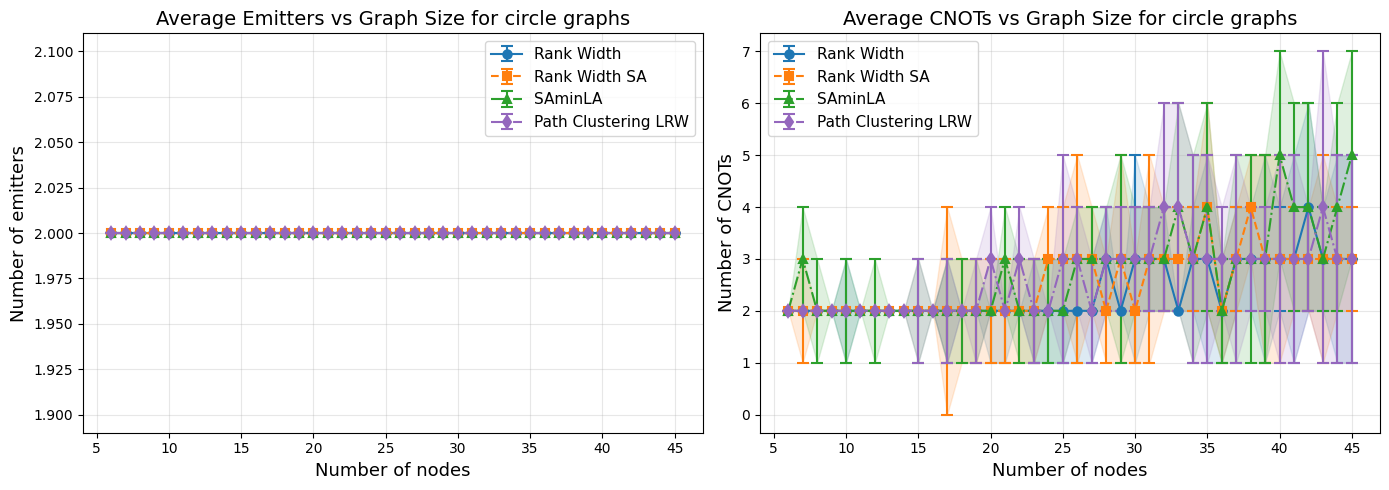

In [123]:
# --- Load saved results for all three methods ---
# Rank Width (exact)
avg_emitters_rw = load_simulation_results('circle_db_rank_width_avg', 'emitters')
std_emitters_rw = load_simulation_results('circle_db_rank_width_std', 'emitters')
avg_cnots_rw = load_simulation_results('circle_db_rank_width_avg', 'cnots')
std_cnots_rw = load_simulation_results('circle_db_rank_width_std', 'cnots')

# Rank Width SA
avg_emitters_rwsa = load_simulation_results('circle_db_rank_width_sa_avg', 'emitters')
std_emitters_rwsa = load_simulation_results('circle_db_rank_width_sa_std', 'emitters')
avg_cnots_rwsa = load_simulation_results('circle_db_rank_width_sa_avg', 'cnots')
std_cnots_rwsa = load_simulation_results('circle_db_rank_width_sa_std', 'cnots')

# SAminLA
avg_emitters_saminla = load_simulation_results('circle_db_saminla_avg', 'emitters')
std_emitters_saminla = load_simulation_results('circle_db_saminla_std', 'emitters')
avg_cnots_saminla = load_simulation_results('circle_db_saminla_avg', 'cnots')
std_cnots_saminla = load_simulation_results('circle_db_saminla_std', 'cnots')

# path clustering linear rank width
avg_emitters_path = load_simulation_results('circle_db_path_clustering_lrw_avg', 'emitters')
std_emitters_path = load_simulation_results('circle_db_path_clustering_lrw_std', 'emitters')
avg_cnots_path = load_simulation_results('circle_db_path_clustering_lrw_avg', 'cnots')
std_cnots_path = load_simulation_results('circle_db_path_clustering_lrw_std', 'cnots')

node_sizes_arr = load_simulation_results('circle_db_saminla', 'node_sizes')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# --- Emitters plot ---
# Rank Width (exact)
ax1.errorbar(node_sizes_arr, avg_emitters_rw, yerr=std_emitters_rw, fmt='o-', capsize=4,
             color='tab:blue', ecolor='tab:blue', elinewidth=1.5, markeredgewidth=1.5, label='Rank Width')
ax1.fill_between(node_sizes_arr, avg_emitters_rw - std_emitters_rw, avg_emitters_rw + std_emitters_rw,
                 alpha=0.15, color='tab:blue')
# Rank Width SA
ax1.errorbar(node_sizes_arr, avg_emitters_rwsa, yerr=std_emitters_rwsa, fmt='s--', capsize=4,
             color='tab:orange', ecolor='tab:orange', elinewidth=1.5, markeredgewidth=1.5, label='Rank Width SA')
ax1.fill_between(node_sizes_arr, avg_emitters_rwsa - std_emitters_rwsa, avg_emitters_rwsa + std_emitters_rwsa,
                 alpha=0.15, color='tab:orange')
# SAminLA
ax1.errorbar(node_sizes_arr, avg_emitters_saminla, yerr=std_emitters_saminla, fmt='^-.', capsize=4,
             color='tab:green', ecolor='tab:green', elinewidth=1.5, markeredgewidth=1.5, label='SAminLA')
ax1.fill_between(node_sizes_arr, avg_emitters_saminla - std_emitters_saminla, avg_emitters_saminla + std_emitters_saminla,
                 alpha=0.15, color='tab:green')
# path clustering linear rank width
ax1.errorbar(node_sizes_arr, avg_emitters_path, yerr=std_emitters_path, fmt='d-.', capsize=4,
             color='tab:purple', ecolor='tab:purple', elinewidth=1.5, markeredgewidth=1.5, label='Path Clustering LRW')
ax1.fill_between(node_sizes_arr, avg_emitters_path - std_emitters_path, avg_emitters_path + std_emitters_path,
                 alpha=0.15, color='tab:purple')

ax1.set_xlabel('Number of nodes', fontsize=13)
ax1.set_ylabel('Number of emitters', fontsize=13)
ax1.set_title('Average Emitters vs Graph Size for circle graphs', fontsize=14)
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)

# --- CNOTs plot ---
# Rank Width (exact)
ax2.errorbar(node_sizes_arr, avg_cnots_rw, yerr=std_cnots_rw, fmt='o-', capsize=4,
             color='tab:blue', ecolor='tab:blue', elinewidth=1.5, markeredgewidth=1.5, label='Rank Width')
ax2.fill_between(node_sizes_arr, avg_cnots_rw - std_cnots_rw, avg_cnots_rw + std_cnots_rw,
                 alpha=0.15, color='tab:blue')
# Rank Width SA
ax2.errorbar(node_sizes_arr, avg_cnots_rwsa, yerr=std_cnots_rwsa, fmt='s--', capsize=4,
             color='tab:orange', ecolor='tab:orange', elinewidth=1.5, markeredgewidth=1.5, label='Rank Width SA')
ax2.fill_between(node_sizes_arr, avg_cnots_rwsa - std_cnots_rwsa, avg_cnots_rwsa + std_cnots_rwsa,
                 alpha=0.15, color='tab:orange')
# SAminLA
ax2.errorbar(node_sizes_arr, avg_cnots_saminla, yerr=std_cnots_saminla, fmt='^-.', capsize=4,
             color='tab:green', ecolor='tab:green', elinewidth=1.5, markeredgewidth=1.5, label='SAminLA')
ax2.fill_between(node_sizes_arr, avg_cnots_saminla - std_cnots_saminla, avg_cnots_saminla + std_cnots_saminla,
                 alpha=0.15, color='tab:green')

# path clustering linear rank width
ax2.errorbar(node_sizes_arr, avg_cnots_path, yerr=std_cnots_path, fmt='d-.', capsize=4,
             color='tab:purple', ecolor='tab:purple', elinewidth=1.5, markeredgewidth=1.5, label='Path Clustering LRW')
ax2.fill_between(node_sizes_arr, avg_cnots_path - std_cnots_path, avg_cnots_path + std_cnots_path,
                 alpha=0.15, color='tab:purple')

ax2.set_xlabel('Number of nodes', fontsize=13)
ax2.set_ylabel('Number of CNOTs', fontsize=13)
ax2.set_title('Average CNOTs vs Graph Size for circle graphs', fontsize=14)
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## create caterpillars

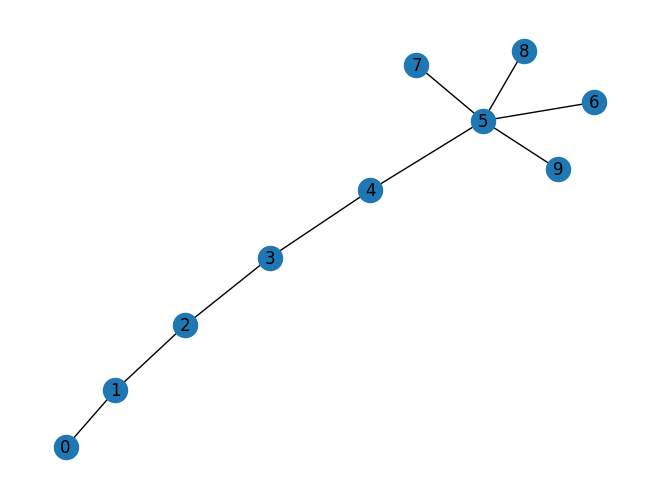

In [ ]:
nx.draw(nx.random_lobster_graph(10, 0.3, 0), with_labels=True)

In [ ]:
# --- Generate caterpillar graph database ---
# nx.random_lobster_graph(n, p1, p2=0) generates a caterpillar where n is the backbone size.
# We want graphs with exactly `target_nodes` total nodes. Strategy:
# Generate caterpillars with varying backbone/p1 until we get one with the target total nodes.

min_nodes_cat = 6
max_nodes_cat = 45
num_variants_cat =30
seed_cat = 42
random.seed(seed_cat)
np.random.seed(seed_cat)

# Output directory
cat_db_path = os.path.join(os.getcwd(), 'cater_database')
os.makedirs(cat_db_path, exist_ok=True)

cater_database = {}  # {target_nodes: [list of 5 nx.Graph objects]}

for target_n in range(min_nodes_cat, max_nodes_cat + 1):
    variants = []
    attempts = 0
    while len(variants) < num_variants_cat and attempts < 50000:
        attempts += 1
        # Try different backbone sizes and p1 values
        backbone = random.randint(max(2, target_n // 3), target_n - 1)
        p1 = random.uniform(0.2, 0.9)
        g = nx.random_lobster_graph(backbone, p1, 0, seed=random.randint(0, 100000))
        
        # Check: non-empty, connected, and has exactly target_n nodes
        if g.number_of_nodes() == target_n and g.number_of_nodes() > 0 and nx.is_connected(g):
            g = nx.convert_node_labels_to_integers(g)
            variants.append(g)
    
    cater_database[target_n] = variants
    if len(variants) < num_variants_cat:
        print(f"  WARNING n={target_n}: only got {len(variants)}/{num_variants_cat} after {attempts} attempts")
    print(f"Caterpillar n={target_n}: generated {len(variants)} variants "
          f"(edges: {[g.number_of_edges() for g in variants]})")

# --- Save individual graphs as edge-lists ---
for n, variants in cater_database.items():
    for v_idx, g in enumerate(variants):
        filepath = os.path.join(cat_db_path, f'cater_n{n}_v{v_idx}.edgelist')
        nx.write_edgelist(g, filepath, data=False)

# --- Save the whole database as a pickle ---
pickle_path_cat = os.path.join(cat_db_path, 'cater_database.pkl')
with open(pickle_path_cat, 'wb') as f:
    pickle.dump(cater_database, f)

print(f"\nCaterpillar database saved to: {cat_db_path}")
print(f"  - {len(cater_database)} graph sizes (n={min_nodes_cat}..{max_nodes_cat})")
print(f"  - {num_variants_cat} variants each")
print(f"  - Total graphs: {sum(len(v) for v in cater_database.values())}")
print(f"  - Pickle file: {pickle_path_cat}")

Loaded 40 graph sizes (n=6..45)
30 variants per size
Total graphs: 1200

Verification: 1200/1200 graphs are valid caterpillars ✓




In [ ]:
# --- Load caterpillar database and plot examples ---
with open('cater_database/cater_database.pkl', 'rb') as f:
    loaded_cater_db = pickle.load(f)

print(f"Loaded {len(loaded_cater_db)} graph sizes (n={min(loaded_cater_db)}..{max(loaded_cater_db)})")
print(f"{len(loaded_cater_db[min(loaded_cater_db)])} variants per size")
print(f"Total graphs: {sum(len(v) for v in loaded_cater_db.values())}")

# --- Helper: verify a graph is a caterpillar ---
def is_caterpillar(G):
    """A tree is a caterpillar iff removing all leaf nodes yields a path (or empty graph)."""
    if not nx.is_tree(G):
        return False
    # Remove all leaves (degree-1 nodes) → should be a path (or empty/single node)
    spine = G.copy()
    leaves = [v for v in spine.nodes() if spine.degree(v) == 1]
    spine.remove_nodes_from(leaves)
    if spine.number_of_nodes() == 0:
        return True  # star graph or single edge — valid caterpillar
    if not nx.is_connected(spine):
        return False
    # A connected graph is a path iff it has exactly 2 nodes of degree 1 and all others degree 2
    # (or it has less than 2 nodes)
    if spine.number_of_nodes() <= 2:
        return True
    degree_seq = sorted(d for _, d in spine.degree())
    return degree_seq[0] == 1 and degree_seq[1] == 1 and all(d == 2 for d in degree_seq[2:])

# --- Verify all graphs ---
cat_sizes = sorted(loaded_cater_db.keys())
total, valid = 0, 0
for n in cat_sizes:
    for v_idx, g in enumerate(loaded_cater_db[n]):
        total += 1
        if is_caterpillar(g):
            valid += 1
        else:
            print(f"  NOT a caterpillar: n={n}, variant {v_idx}")
print(f"\nVerification: {valid}/{total} graphs are valid caterpillars ✓")

# --- Plot grid: 3 variants per node size ---
num_to_show = min(3, len(loaded_cater_db[cat_sizes[0]]))  # show up to 3 variants
nrows = len(cat_sizes)
ncols = num_to_show

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
if nrows == 1:
    axes = axes[np.newaxis, :]
if ncols == 1:
    axes = axes[:, np.newaxis]

for row, n in enumerate(cat_sizes):
    for col in range(num_to_show):
        g = loaded_cater_db[n][col]
        ax = axes[row, col]
        
        # Highlight the spine (backbone) vs leaves
        spine = g.copy()
        leaves = [v for v in spine.nodes() if spine.degree(v) == 1]
        spine_nodes = [v for v in g.nodes() if v not in leaves]
        
        pos = nx.spring_layout(g, seed=42 + col)
        # Draw leaf nodes
        nx.draw_networkx_nodes(g, pos, nodelist=leaves, ax=ax,
                               node_color='lightyellow', edgecolors='orange',
                               node_size=300, linewidths=1.5)
        # Draw spine nodes
        nx.draw_networkx_nodes(g, pos, nodelist=spine_nodes, ax=ax,
                               node_color='lightcoral', edgecolors='darkred',
                               node_size=400, linewidths=1.5)
        nx.draw_networkx_edges(g, pos, ax=ax, edge_color='gray', width=1.5)
        nx.draw_networkx_labels(g, pos, ax=ax, font_size=8)
        
        n_leaves = len(leaves)
        n_spine = len(spine_nodes)
        ax.set_title(f'n={n}, v={col}\n{n_spine} spine + {n_leaves} leaves, {g.number_of_edges()} edges',
                     fontsize=10)

fig.suptitle('Caterpillar Graph Examples\n(red = spine/backbone, yellow = leaves)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## Caterpillar - Rank Width

In [85]:
# --- Benchmark: Rank Width (exact) on caterpillar database ---
results_cat_rw = defaultdict(lambda: {'emitters': [], 'cnots': []})
avg_emitters_cat_rw = []
std_emitters_cat_rw = []
avg_cnots_cat_rw = []
std_cnots_cat_rw = []
cat_node_sizes = sorted(loaded_cater_db.keys())

for n_nodes in cat_node_sizes:
    variants = loaded_cater_db[n_nodes]
    emitters_list = []
    cnots_list = []
    print(f"------------Processing n={n_nodes} with {len(variants)} variants...------------")
    for v_idx, G in enumerate(variants):
        print(f"  Variant {v_idx}")
        try:
            G = edge_reduction_func(G)
            cost, final_ordering = linear_rank_width(G)
            print(f"    n={n_nodes}, variant {v_idx}: ordering found (lrw={cost})")
            ordered_graph = nx.relabel_nodes(G, {old: new for new, old in enumerate(final_ordering)})
            opt_graph, circuit, stats = run_optimization(ordered_graph, edge_reduction=False, minLA=False, opt_CNOT=True)
            emitters_list.append(stats[0])
            cnots_list.append(stats[1])
        except Exception as e:
            print(f"    ERROR n={n_nodes}, variant {v_idx}: {e}")

    results_cat_rw[n_nodes]['emitters'] = emitters_list
    results_cat_rw[n_nodes]['cnots'] = cnots_list
    avg_e = np.mean(emitters_list); std_e = np.std(emitters_list)
    avg_c = np.mean(cnots_list); std_c = np.std(cnots_list)
    avg_emitters_cat_rw.append(avg_e); std_emitters_cat_rw.append(std_e)
    avg_cnots_cat_rw.append(avg_c); std_cnots_cat_rw.append(std_c)
    print(f"  n={n_nodes}: emitters={avg_e:.2f}±{std_e:.2f}, cnots={avg_c:.2f}±{std_c:.2f}\n")

# Save results
save_simulation_results(avg_emitters_cat_rw, 'cater_db_rank_width_avg', 'emitters')
save_simulation_results(avg_cnots_cat_rw, 'cater_db_rank_width_avg', 'cnots')
save_simulation_results(std_emitters_cat_rw, 'cater_db_rank_width_std', 'emitters')
save_simulation_results(std_cnots_cat_rw, 'cater_db_rank_width_std', 'cnots')
all_emitters_cat_rw = np.array([results_cat_rw[n]['emitters'] for n in cat_node_sizes])
all_cnots_cat_rw = np.array([results_cat_rw[n]['cnots'] for n in cat_node_sizes])
save_simulation_results(all_emitters_cat_rw, 'cater_db_rank_width_raw', 'emitters')
save_simulation_results(all_cnots_cat_rw, 'cater_db_rank_width_raw', 'cnots')
save_simulation_results(cat_node_sizes, 'cater_db_rank_width', 'node_sizes')
print(f"\nDone! Processed {len(cat_node_sizes)} graph sizes × {len(variants)} variants = {len(cat_node_sizes)*len(variants)} graphs")

------------Processing n=6 with 30 variants...------------
  Variant 0
    n=6, variant 0: ordering found (lrw=1)
  Variant 1
    n=6, variant 1: ordering found (lrw=1)
  Variant 2
    n=6, variant 2: ordering found (lrw=1)
  Variant 3
    n=6, variant 3: ordering found (lrw=1)
  Variant 4
    n=6, variant 2: ordering found (lrw=1)
  Variant 3
    n=6, variant 3: ordering found (lrw=1)
  Variant 4
    n=6, variant 4: ordering found (lrw=1)
  Variant 5
    n=6, variant 5: ordering found (lrw=1)
  Variant 6
    n=6, variant 6: ordering found (lrw=1)
  Variant 7
    n=6, variant 4: ordering found (lrw=1)
  Variant 5
    n=6, variant 5: ordering found (lrw=1)
  Variant 6
    n=6, variant 6: ordering found (lrw=1)
  Variant 7
    n=6, variant 7: ordering found (lrw=1)
  Variant 8
    n=6, variant 8: ordering found (lrw=1)
  Variant 9
    n=6, variant 9: ordering found (lrw=1)
  Variant 10
    n=6, variant 7: ordering found (lrw=1)
  Variant 8
    n=6, variant 8: ordering found (lrw=1)
  Var

## Caterpillar - Rank Width SA

In [86]:
# --- Benchmark: Rank Width SA on caterpillar database ---
results_cat_rwsa = defaultdict(lambda: {'emitters': [], 'cnots': []})
avg_emitters_cat_rwsa = []
std_emitters_cat_rwsa = []
avg_cnots_cat_rwsa = []
std_cnots_cat_rwsa = []
cat_node_sizes = sorted(loaded_cater_db.keys())

for n_nodes in cat_node_sizes:
    variants = loaded_cater_db[n_nodes]
    emitters_list = []
    cnots_list = []
    print(f"------------Processing n={n_nodes} with {len(variants)} variants...------------")
    for v_idx, G in enumerate(variants):
        print(f"  Variant {v_idx}")
        try:
            G = edge_reduction_func(G)
            cost, final_ordering = linear_rank_width_sa(G)
            print(f"    n={n_nodes}, variant {v_idx}: ordering found (lrw={cost})")
            ordered_graph = nx.relabel_nodes(G, {old: new for new, old in enumerate(final_ordering)})
            opt_graph, circuit, stats = run_optimization(ordered_graph, edge_reduction=False, minLA=False, opt_CNOT=True)
            emitters_list.append(stats[0])
            cnots_list.append(stats[1])
        except Exception as e:
            print(f"    ERROR n={n_nodes}, variant {v_idx}: {e}")

    results_cat_rwsa[n_nodes]['emitters'] = emitters_list
    results_cat_rwsa[n_nodes]['cnots'] = cnots_list
    avg_e = np.mean(emitters_list); std_e = np.std(emitters_list)
    avg_c = np.mean(cnots_list); std_c = np.std(cnots_list)
    avg_emitters_cat_rwsa.append(avg_e); std_emitters_cat_rwsa.append(std_e)
    avg_cnots_cat_rwsa.append(avg_c); std_cnots_cat_rwsa.append(std_c)
    print(f"  n={n_nodes}: emitters={avg_e:.2f}±{std_e:.2f}, cnots={avg_c:.2f}±{std_c:.2f}\n")

# Save results
save_simulation_results(avg_emitters_cat_rwsa, 'cater_db_rank_width_sa_avg', 'emitters')
save_simulation_results(avg_cnots_cat_rwsa, 'cater_db_rank_width_sa_avg', 'cnots')
save_simulation_results(std_emitters_cat_rwsa, 'cater_db_rank_width_sa_std', 'emitters')
save_simulation_results(std_cnots_cat_rwsa, 'cater_db_rank_width_sa_std', 'cnots')
all_emitters_cat_rwsa = np.array([results_cat_rwsa[n]['emitters'] for n in cat_node_sizes])
all_cnots_cat_rwsa = np.array([results_cat_rwsa[n]['cnots'] for n in cat_node_sizes])
save_simulation_results(all_emitters_cat_rwsa, 'cater_db_rank_width_sa_raw', 'emitters')
save_simulation_results(all_cnots_cat_rwsa, 'cater_db_rank_width_sa_raw', 'cnots')
save_simulation_results(cat_node_sizes, 'cater_db_rank_width_sa', 'node_sizes')
print(f"\nDone! Processed {len(cat_node_sizes)} graph sizes × {len(variants)} variants = {len(cat_node_sizes)*len(variants)} graphs")

------------Processing n=6 with 30 variants...------------
  Variant 0
    n=6, variant 0: ordering found (lrw=1)
  Variant 1
    n=6, variant 0: ordering found (lrw=1)
  Variant 1
    n=6, variant 1: ordering found (lrw=1)
  Variant 2
    n=6, variant 1: ordering found (lrw=1)
  Variant 2
    n=6, variant 2: ordering found (lrw=1)
  Variant 3
    n=6, variant 2: ordering found (lrw=1)
  Variant 3
    n=6, variant 3: ordering found (lrw=1)
  Variant 4
    n=6, variant 3: ordering found (lrw=1)
  Variant 4
    n=6, variant 4: ordering found (lrw=1)
  Variant 5
    n=6, variant 4: ordering found (lrw=1)
  Variant 5
    n=6, variant 5: ordering found (lrw=1)
  Variant 6
    n=6, variant 5: ordering found (lrw=1)
  Variant 6
    n=6, variant 6: ordering found (lrw=1)
  Variant 7
    n=6, variant 6: ordering found (lrw=1)
  Variant 7
    n=6, variant 7: ordering found (lrw=1)
  Variant 8
    n=6, variant 7: ordering found (lrw=1)
  Variant 8
    n=6, variant 8: ordering found (lrw=1)
  Vari

## Caterpillar-path_clustering

In [120]:
# --- Benchmark: Rank Width SA on caterpillar database ---
results_cat_path = defaultdict(lambda: {'emitters': [], 'cnots': []})
avg_emitters_cat_path = []
std_emitters_cat_path = []
avg_cnots_cat_path = []
std_cnots_cat_path = []
cat_node_sizes = sorted(loaded_cater_db.keys())

for n_nodes in cat_node_sizes:
    variants = loaded_cater_db[n_nodes]
    emitters_list = []
    cnots_list = []
    print(f"------------Processing n={n_nodes} with {len(variants)} variants...------------")
    for v_idx, G in enumerate(variants):
        print(f"  Variant {v_idx}")
        try:
            G = edge_reduction_func(G)
            cost, final_ordering = path_clustering_lrw(G)
            print(f"    n={n_nodes}, variant {v_idx}: ordering found (lrw={cost})")
            ordered_graph = nx.relabel_nodes(G, {old: new for new, old in enumerate(final_ordering)})
            opt_graph, circuit, stats = run_optimization(ordered_graph, edge_reduction=False, minLA=False, opt_CNOT=True)
            emitters_list.append(stats[0])
            cnots_list.append(stats[1])
        except Exception as e:
            print(f"    ERROR n={n_nodes}, variant {v_idx}: {e}")

    results_cat_path[n_nodes]['emitters'] = emitters_list
    results_cat_path[n_nodes]['cnots'] = cnots_list
    avg_e = np.mean(emitters_list); std_e = np.std(emitters_list)
    avg_c = np.mean(cnots_list); std_c = np.std(cnots_list)
    avg_emitters_cat_path.append(avg_e); std_emitters_cat_path.append(std_e)
    avg_cnots_cat_path.append(avg_c); std_cnots_cat_path.append(std_c)
    print(f"  n={n_nodes}: emitters={avg_e:.2f}±{std_e:.2f}, cnots={avg_c:.2f}±{std_c:.2f}\n")

# Save results
save_simulation_results(avg_emitters_cat_path, 'cater_db_path_clustering_lrw_avg', 'emitters')
save_simulation_results(avg_cnots_cat_path, 'cater_db_path_clustering_lrw_avg', 'cnots')
save_simulation_results(std_emitters_cat_path, 'cater_db_path_clustering_lrw_std', 'emitters')
save_simulation_results(std_cnots_cat_path, 'cater_db_path_clustering_lrw_std', 'cnots')
all_emitters_cat_path = np.array([results_cat_path[n]['emitters'] for n in cat_node_sizes])
all_cnots_cat_path = np.array([results_cat_path[n]['cnots'] for n in cat_node_sizes])
save_simulation_results(all_emitters_cat_path, 'cater_db_path_clustering_lrw_raw', 'emitters')
save_simulation_results(all_cnots_cat_path, 'cater_db_path_clustering_lrw_raw', 'cnots')
save_simulation_results(cat_node_sizes, 'cater_db_path_clustering_lrw', 'node_sizes')
print(f"\nDone! Processed {len(cat_node_sizes)} graph sizes × {len(variants)} variants = {len(cat_node_sizes)*len(variants)} graphs")

------------Processing n=6 with 30 variants...------------
  Variant 0
    n=6, variant 0: ordering found (lrw=1)
  Variant 1
    n=6, variant 1: ordering found (lrw=1)
  Variant 2
    n=6, variant 2: ordering found (lrw=1)
  Variant 3
    n=6, variant 3: ordering found (lrw=1)
  Variant 4
    n=6, variant 4: ordering found (lrw=1)
  Variant 5
    n=6, variant 5: ordering found (lrw=1)
  Variant 6
    n=6, variant 6: ordering found (lrw=1)
  Variant 7
    n=6, variant 7: ordering found (lrw=1)
  Variant 8
    n=6, variant 8: ordering found (lrw=1)
  Variant 9
    n=6, variant 9: ordering found (lrw=1)
  Variant 10
    n=6, variant 10: ordering found (lrw=1)
  Variant 11
    n=6, variant 11: ordering found (lrw=1)
  Variant 12
    n=6, variant 12: ordering found (lrw=1)
  Variant 13
    n=6, variant 13: ordering found (lrw=1)
  Variant 14
    n=6, variant 14: ordering found (lrw=1)
  Variant 15
    n=6, variant 15: ordering found (lrw=1)
  Variant 16
    n=6, variant 16: ordering found 

## Caterpillar - SAminLA

In [87]:
# --- Benchmark: SAminLA on caterpillar database ---
results_cat_saminla = defaultdict(lambda: {'emitters': [], 'cnots': []})
avg_emitters_cat_saminla = []
std_emitters_cat_saminla = []
avg_cnots_cat_saminla = []
std_cnots_cat_saminla = []
cat_node_sizes = sorted(loaded_cater_db.keys())

for n_nodes in cat_node_sizes:
    variants = loaded_cater_db[n_nodes]
    emitters_list = []
    cnots_list = []
    print(f"------------Processing n={n_nodes} with {len(variants)} variants...------------")
    for v_idx, G in enumerate(variants):
        print(f"  Variant {v_idx}")
        try:
            opt_graph, circuit, stats = run_optimization(G, opt_CNOT=True)
            emitters_list.append(stats[0])
            cnots_list.append(stats[1])
            print(f"    n={n_nodes}, variant {v_idx}: emitters={stats[0]}, cnots={stats[1]}")
        except Exception as e:
            print(f"    ERROR n={n_nodes}, variant {v_idx}: {e}")

    results_cat_saminla[n_nodes]['emitters'] = emitters_list
    results_cat_saminla[n_nodes]['cnots'] = cnots_list
    avg_e = np.mean(emitters_list); std_e = np.std(emitters_list)
    avg_c = np.mean(cnots_list); std_c = np.std(cnots_list)
    avg_emitters_cat_saminla.append(avg_e); std_emitters_cat_saminla.append(std_e)
    avg_cnots_cat_saminla.append(avg_c); std_cnots_cat_saminla.append(std_c)
    print(f"  n={n_nodes}: emitters={avg_e:.2f}±{std_e:.2f}, cnots={avg_c:.2f}±{std_c:.2f}\n")

# Save results
save_simulation_results(avg_emitters_cat_saminla, 'cater_db_saminla_avg', 'emitters')
save_simulation_results(avg_cnots_cat_saminla, 'cater_db_saminla_avg', 'cnots')
save_simulation_results(std_emitters_cat_saminla, 'cater_db_saminla_std', 'emitters')
save_simulation_results(std_cnots_cat_saminla, 'cater_db_saminla_std', 'cnots')
all_emitters_cat_saminla = np.array([results_cat_saminla[n]['emitters'] for n in cat_node_sizes])
all_cnots_cat_saminla = np.array([results_cat_saminla[n]['cnots'] for n in cat_node_sizes])
save_simulation_results(all_emitters_cat_saminla, 'cater_db_saminla_raw', 'emitters')
save_simulation_results(all_cnots_cat_saminla, 'cater_db_saminla_raw', 'cnots')
save_simulation_results(cat_node_sizes, 'cater_db_saminla', 'node_sizes')
print(f"\nDone! Processed {len(cat_node_sizes)} graph sizes × {len(variants)} variants = {len(cat_node_sizes)*len(variants)} graphs")

------------Processing n=6 with 30 variants...------------
  Variant 0
    n=6, variant 0: emitters=1, cnots=0
  Variant 1
    n=6, variant 0: emitters=1, cnots=0
  Variant 1
    n=6, variant 1: emitters=1, cnots=0
  Variant 2
    n=6, variant 1: emitters=1, cnots=0
  Variant 2
    n=6, variant 2: emitters=1, cnots=0
  Variant 3
    n=6, variant 2: emitters=1, cnots=0
  Variant 3
    n=6, variant 3: emitters=1, cnots=0
  Variant 4
    n=6, variant 3: emitters=1, cnots=0
  Variant 4
    n=6, variant 4: emitters=1, cnots=0
  Variant 5
    n=6, variant 4: emitters=1, cnots=0
  Variant 5
    n=6, variant 5: emitters=1, cnots=0
  Variant 6
    n=6, variant 5: emitters=1, cnots=0
  Variant 6
    n=6, variant 6: emitters=1, cnots=0
  Variant 7
    n=6, variant 6: emitters=1, cnots=0
  Variant 7
    n=6, variant 7: emitters=1, cnots=0
  Variant 8
    n=6, variant 7: emitters=1, cnots=0
  Variant 8
    n=6, variant 8: emitters=1, cnots=0
  Variant 9
    n=6, variant 8: emitters=1, cnots=0
  Var

## Plotting caterpillars

Loaded emitters data from: /Users/konstantinosrafailrevis/Desktop/PhD/photonic_state_generation/simulations_data/repeater_graph_emitters_cater_db_rank_width_avg.txt
Loaded emitters data from: /Users/konstantinosrafailrevis/Desktop/PhD/photonic_state_generation/simulations_data/repeater_graph_emitters_cater_db_rank_width_std.txt
Loaded cnots data from: /Users/konstantinosrafailrevis/Desktop/PhD/photonic_state_generation/simulations_data/repeater_graph_cnots_cater_db_rank_width_avg.txt
Loaded cnots data from: /Users/konstantinosrafailrevis/Desktop/PhD/photonic_state_generation/simulations_data/repeater_graph_cnots_cater_db_rank_width_std.txt
Loaded emitters data from: /Users/konstantinosrafailrevis/Desktop/PhD/photonic_state_generation/simulations_data/repeater_graph_emitters_cater_db_rank_width_sa_avg.txt
Loaded emitters data from: /Users/konstantinosrafailrevis/Desktop/PhD/photonic_state_generation/simulations_data/repeater_graph_emitters_cater_db_rank_width_sa_std.txt
Loaded cnots dat

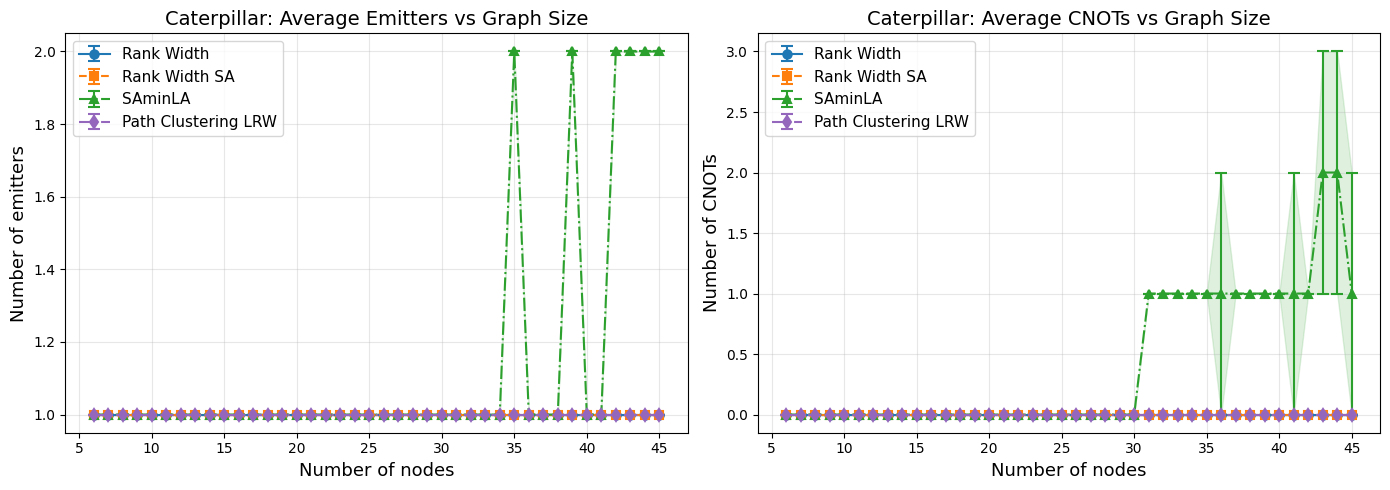

In [125]:
# --- Load and plot caterpillar results for all three methods ---
# Rank Width (exact)
avg_em_cat_rw = load_simulation_results('cater_db_rank_width_avg', 'emitters')
std_em_cat_rw = load_simulation_results('cater_db_rank_width_std', 'emitters')
avg_cn_cat_rw = load_simulation_results('cater_db_rank_width_avg', 'cnots')
std_cn_cat_rw = load_simulation_results('cater_db_rank_width_std', 'cnots')

# Rank Width SA
avg_em_cat_rwsa = load_simulation_results('cater_db_rank_width_sa_avg', 'emitters')
std_em_cat_rwsa = load_simulation_results('cater_db_rank_width_sa_std', 'emitters')
avg_cn_cat_rwsa = load_simulation_results('cater_db_rank_width_sa_avg', 'cnots')
std_cn_cat_rwsa = load_simulation_results('cater_db_rank_width_sa_std', 'cnots')

# SAminLA
avg_em_cat_saminla = load_simulation_results('cater_db_saminla_avg', 'emitters')
std_em_cat_saminla = load_simulation_results('cater_db_saminla_std', 'emitters')
avg_cn_cat_saminla = load_simulation_results('cater_db_saminla_avg', 'cnots')
std_cn_cat_saminla = load_simulation_results('cater_db_saminla_std', 'cnots')

# path clustering linear rank width
avg_em_cat_path = load_simulation_results('cater_db_path_clustering_lrw_avg', 'emitters')
std_em_cat_path = load_simulation_results('cater_db_path_clustering_lrw_std', 'emitters')
avg_cn_cat_path = load_simulation_results('cater_db_path_clustering_lrw_avg', 'cnots')
std_cn_cat_path = load_simulation_results('cater_db_path_clustering_lrw_std', 'cnots')

cat_node_sizes_arr = load_simulation_results('cater_db_saminla', 'node_sizes')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# --- Emitters plot ---
ax1.errorbar(cat_node_sizes_arr, avg_em_cat_rw, yerr=std_em_cat_rw, fmt='o-', capsize=4,
             color='tab:blue', elinewidth=1.5, markeredgewidth=1.5, label='Rank Width')
ax1.fill_between(cat_node_sizes_arr, avg_em_cat_rw - std_em_cat_rw, avg_em_cat_rw + std_em_cat_rw,
                 alpha=0.15, color='tab:blue')
ax1.errorbar(cat_node_sizes_arr, avg_em_cat_rwsa, yerr=std_em_cat_rwsa, fmt='s--', capsize=4,
             color='tab:orange', elinewidth=1.5, markeredgewidth=1.5, label='Rank Width SA')
ax1.fill_between(cat_node_sizes_arr, avg_em_cat_rwsa - std_em_cat_rwsa, avg_em_cat_rwsa + std_em_cat_rwsa,
                 alpha=0.15, color='tab:orange')
ax1.errorbar(cat_node_sizes_arr, avg_em_cat_saminla, yerr=std_em_cat_saminla, fmt='^-.', capsize=4,
             color='tab:green', elinewidth=1.5, markeredgewidth=1.5, label='SAminLA')
ax1.fill_between(cat_node_sizes_arr, avg_em_cat_saminla - std_em_cat_saminla, avg_em_cat_saminla + std_em_cat_saminla,
                 alpha=0.15, color='tab:green')
ax1.errorbar(cat_node_sizes_arr, avg_em_cat_path, yerr=std_em_cat_path, fmt='d-.', capsize=4,
             color='tab:purple', elinewidth=1.5, markeredgewidth=1.5, label='Path Clustering LRW')
ax1.fill_between(cat_node_sizes_arr, avg_em_cat_path - std_em_cat_path, avg_em_cat_path + std_em_cat_path,
                 alpha=0.15, color='tab:purple')
ax1.set_xlabel('Number of nodes', fontsize=13)
ax1.set_ylabel('Number of emitters', fontsize=13)
ax1.set_title('Caterpillar: Average Emitters vs Graph Size', fontsize=14)
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)

# --- CNOTs plot ---
ax2.errorbar(cat_node_sizes_arr, avg_cn_cat_rw, yerr=std_cn_cat_rw, fmt='o-', capsize=4,
             color='tab:blue', elinewidth=1.5, markeredgewidth=1.5, label='Rank Width')
ax2.fill_between(cat_node_sizes_arr, avg_cn_cat_rw - std_cn_cat_rw, avg_cn_cat_rw + std_cn_cat_rw,
                 alpha=0.15, color='tab:blue')
ax2.errorbar(cat_node_sizes_arr, avg_cn_cat_rwsa, yerr=std_cn_cat_rwsa, fmt='s--', capsize=4,
             color='tab:orange', elinewidth=1.5, markeredgewidth=1.5, label='Rank Width SA')
ax2.fill_between(cat_node_sizes_arr, avg_cn_cat_rwsa - std_cn_cat_rwsa, avg_cn_cat_rwsa + std_cn_cat_rwsa,
                 alpha=0.15, color='tab:orange')
ax2.errorbar(cat_node_sizes_arr, avg_cn_cat_saminla, yerr=std_cn_cat_saminla, fmt='^-.', capsize=4,
             color='tab:green', elinewidth=1.5, markeredgewidth=1.5, label='SAminLA')
ax2.fill_between(cat_node_sizes_arr, avg_cn_cat_saminla - std_cn_cat_saminla, avg_cn_cat_saminla + std_cn_cat_saminla,
                 alpha=0.15, color='tab:green')
ax2.errorbar(cat_node_sizes_arr, avg_cn_cat_path, yerr=std_cn_cat_path, fmt='d-.', capsize=4,
             color='tab:purple', elinewidth=1.5, markeredgewidth=1.5, label='Path Clustering LRW')
ax2.fill_between(cat_node_sizes_arr, avg_cn_cat_path - std_cn_cat_path, avg_cn_cat_path + std_cn_cat_path,
                 alpha=0.15, color='tab:purple')
ax2.set_xlabel('Number of nodes', fontsize=13)
ax2.set_ylabel('Number of CNOTs', fontsize=13)
ax2.set_title('Caterpillar: Average CNOTs vs Graph Size', fontsize=14)
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Deutsch Jozsa graphs



In [90]:
# --- Load DJ graphs database and print info ---
with open('dj_graphs/dj_graphs_all.pkl', 'rb') as f:
    loaded_dj_db = pickle.load(f)

print(f"DJ Graphs Database: {len(loaded_dj_db)} graphs (n=1..{max(loaded_dj_db.keys())})")
print(f"Each key maps to a single nx.Graph (Deutsch-Jozsa graph)\n")

print(f"{'Graph n':>10} | {'Vertices':>10} | {'Edges':>10}")
print("-" * 38)
for n in sorted(loaded_dj_db.keys()):
    g = loaded_dj_db[n]
    print(f"{'n=' + str(n):>10} | {g.number_of_nodes():>10} | {g.number_of_edges():>10}")

DJ Graphs Database: 100 graphs (n=1..100)
Each key maps to a single nx.Graph (Deutsch-Jozsa graph)

   Graph n |   Vertices |      Edges
--------------------------------------
       n=1 |          9 |          8
       n=2 |         14 |         13
       n=3 |         19 |         18
       n=4 |         24 |         23
       n=5 |         29 |         28
       n=6 |         34 |         33
       n=7 |         39 |         38
       n=8 |         44 |         43
       n=9 |         49 |         48
      n=10 |         54 |         53
      n=11 |         59 |         58
      n=12 |         64 |         63
      n=13 |         69 |         68
      n=14 |         74 |         73
      n=15 |         79 |         78
      n=16 |         84 |         83
      n=17 |         89 |         88
      n=18 |         94 |         93
      n=19 |         99 |         98
      n=20 |        104 |        103
      n=21 |        109 |        108
      n=22 |        114 |        113
      n=23

In [110]:
#choose the maximum n for which we have a graph for 40 we have around 200 vertices
dj_max = 40



In [111]:
# --- Plot DJ graph examples ---
dj_keys_test = sorted(loaded_dj_db.keys())[:dj_max]

fig, axes = plt.subplots(1, len(dj_keys_test), figsize=(5 * len(dj_keys_test), 5))
if len(dj_keys_test) == 1:
    axes = [axes]

for idx, n in enumerate(dj_keys_test):
    g = loaded_dj_db[n]
    ax = axes[idx]
    pos = nx.spring_layout(g, seed=42)
    nx.draw(g, pos, ax=ax, with_labels=True, node_color='lightskyblue',
            edge_color='gray', node_size=200, font_size=6)
    ax.set_title(f'DJ n={n}\n{g.number_of_nodes()} vertices, {g.number_of_edges()} edges', fontsize=11)

fig.suptitle('Deutsch-Jozsa Graph Examples', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

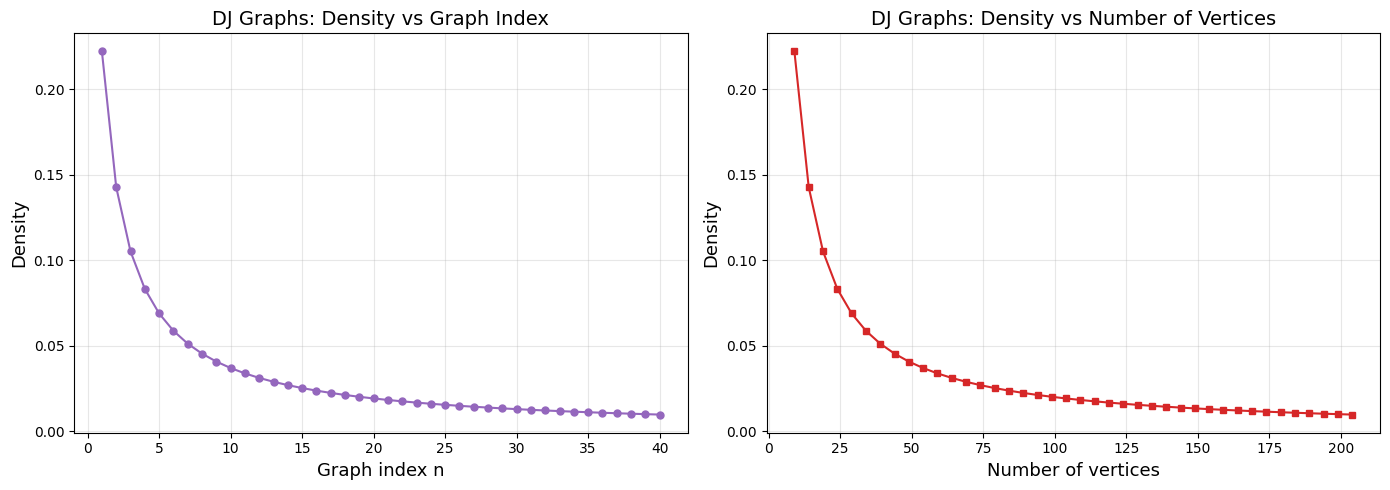


    n |   Vertices |    Edges |    Density
------------------------------------------
    1 |          9 |        8 |   0.222222
    2 |         14 |       13 |   0.142857
    3 |         19 |       18 |   0.105263
    4 |         24 |       23 |   0.083333
    5 |         29 |       28 |   0.068966
    6 |         34 |       33 |   0.058824
    7 |         39 |       38 |   0.051282
    8 |         44 |       43 |   0.045455
    9 |         49 |       48 |   0.040816
   10 |         54 |       53 |   0.037037
   11 |         59 |       58 |   0.033898
   12 |         64 |       63 |   0.031250
   13 |         69 |       68 |   0.028986
   14 |         74 |       73 |   0.027027
   15 |         79 |       78 |   0.025316
   16 |         84 |       83 |   0.023810
   17 |         89 |       88 |   0.022472
   18 |         94 |       93 |   0.021277
   19 |         99 |       98 |   0.020202
   20 |        104 |      103 |   0.019231
   21 |        109 |      108 |   0.018349
   22 |   

In [ ]:
# --- Calculate and plot graph density for DJ graphs ---
# They are trees so we already know they are sparse
dj_keys = sorted(loaded_dj_db.keys())[:dj_max]

dj_vertices = []
dj_edges = []
dj_densities = []

for n in dj_keys:
    g = loaded_dj_db[n]
    v = g.number_of_nodes()
    e = g.number_of_edges()
    d = nx.density(g)
    dj_vertices.append(v)
    dj_edges.append(e)
    dj_densities.append(d)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# --- Density vs graph index n ---
ax1.plot(dj_keys, dj_densities, 'o-', color='tab:purple', markersize=5, linewidth=1.5)
ax1.set_xlabel('Graph index n', fontsize=13)
ax1.set_ylabel('Density', fontsize=13)
ax1.set_title('DJ Graphs: Density vs Graph Index', fontsize=14)
ax1.grid(True, alpha=0.3)

# --- Density vs number of vertices ---
ax2.plot(dj_vertices, dj_densities, 's-', color='tab:red', markersize=5, linewidth=1.5)
ax2.set_xlabel('Number of vertices', fontsize=13)
ax2.set_ylabel('Density', fontsize=13)
ax2.set_title('DJ Graphs: Density vs Number of Vertices', fontsize=14)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print summary
print(f"\n{'n':>5} | {'Vertices':>10} | {'Edges':>8} | {'Density':>10}")
print("-" * 42)
for n, v, e, d in zip(dj_keys, dj_vertices, dj_edges, dj_densities):
    print(f"{n:>5} | {v:>10} | {e:>8} | {d:>10.6f}")

## DJ Graphs - Rank Width

In [113]:
# --- Benchmark: Rank Width (exact) on DJ graphs ---
# DJ DB has 1 graph per key (no variants), so no std across variants.
# We store one emitter/cnot value per graph index n.

dj_keys_test = sorted(loaded_dj_db.keys())[:dj_max]

dj_emitters_rw = []
dj_cnots_rw = []
dj_node_sizes_rw = []

for n in dj_keys_test:
    G = loaded_dj_db[n].copy()
    print(f"------------Processing DJ n={n} ({G.number_of_nodes()} vertices, {G.number_of_edges()} edges)...------------")
    try:
        G = edge_reduction_func(G)
        cost, final_ordering = linear_rank_width(G)
        print(f"  Ordering found (lrw={cost})")
        ordered_graph = nx.relabel_nodes(G, {old: new for new, old in enumerate(final_ordering)})
        opt_graph, circuit, stats = run_optimization(ordered_graph, edge_reduction=False, minLA=False, opt_CNOT=True)
        dj_emitters_rw.append(stats[0])
        dj_cnots_rw.append(stats[1])
        dj_node_sizes_rw.append(G.number_of_nodes())
        print(f"  emitters={stats[0]}, cnots={stats[1]}")
    except Exception as e:
        print(f"  ERROR DJ n={n}: {e}")

# Save results
save_simulation_results(dj_emitters_rw, 'dj_db_rank_width', 'emitters', db_name='dj_edu')
save_simulation_results(dj_cnots_rw, 'dj_db_rank_width', 'cnots', db_name='dj_edu')
save_simulation_results(dj_node_sizes_rw, 'dj_db_rank_width', 'node_sizes', db_name='dj_edu')
print(f"\nDone! Processed {len(dj_keys_test)} DJ graphs with Rank Width")

------------Processing DJ n=1 (9 vertices, 8 edges)...------------
  Ordering found (lrw=1)
  Ordering found (lrw=1)
  emitters=1, cnots=0
------------Processing DJ n=2 (14 vertices, 13 edges)...------------
  emitters=1, cnots=0
------------Processing DJ n=2 (14 vertices, 13 edges)...------------
  Ordering found (lrw=2)
  emitters=2, cnots=1
------------Processing DJ n=3 (19 vertices, 18 edges)...------------
  Ordering found (lrw=2)
  emitters=2, cnots=1
------------Processing DJ n=3 (19 vertices, 18 edges)...------------
  Ordering found (lrw=2)
  emitters=2, cnots=2
------------Processing DJ n=4 (24 vertices, 23 edges)...------------
  Ordering found (lrw=2)
  emitters=2, cnots=2
------------Processing DJ n=4 (24 vertices, 23 edges)...------------
  Ordering found (lrw=2)
  emitters=2, cnots=3
------------Processing DJ n=5 (29 vertices, 28 edges)...------------
  Ordering found (lrw=2)
  emitters=2, cnots=3
------------Processing DJ n=5 (29 vertices, 28 edges)...------------
  Ord

## DJ Graphs - Rank Width SA

In [ ]:
# --- Benchmark: Rank Width SA on DJ graphs ---
dj_keys_test = sorted(loaded_dj_db.keys())[:dj_max]

dj_emitters_rwsa = []
dj_cnots_rwsa = []
dj_node_sizes_rwsa = []

for n in dj_keys_test:
    G = loaded_dj_db[n].copy()
    print(f"------------Processing DJ n={n} ({G.number_of_nodes()} vertices, {G.number_of_edges()} edges)...------------")
    try:
        G = edge_reduction_func(G)
        cost, final_ordering = linear_rank_width_sa(G)
        print(f"  Ordering found (lrw={cost})")
        ordered_graph = nx.relabel_nodes(G, {old: new for new, old in enumerate(final_ordering)})
        opt_graph, circuit, stats = run_optimization(ordered_graph, edge_reduction=False, minLA=False, opt_CNOT=True)
        dj_emitters_rwsa.append(stats[0])
        dj_cnots_rwsa.append(stats[1])
        dj_node_sizes_rwsa.append(G.number_of_nodes())
        print(f"  emitters={stats[0]}, cnots={stats[1]}")
    except Exception as e:
        print(f"  ERROR DJ n={n}: {e}")
# Save results
save_simulation_results(dj_emitters_rwsa, 'dj_db_rank_width_sa', 'emitters', db_name='dj_edu')
save_simulation_results(dj_cnots_rwsa, 'dj_db_rank_width_sa', 'cnots', db_name='dj_edu')
save_simulation_results(dj_node_sizes_rwsa, 'dj_db_rank_width_sa', 'node_sizes', db_name='dj_edu')
print(f"\nDone! Processed {len(dj_keys_test)} DJ graphs with Rank Width SA")

------------Processing DJ n=1 (9 vertices, 8 edges)...------------
  Ordering found (lrw=1)
  emitters=1, cnots=0
------------Processing DJ n=2 (14 vertices, 13 edges)...------------
  Ordering found (lrw=1)
  emitters=1, cnots=0
------------Processing DJ n=2 (14 vertices, 13 edges)...------------
  Ordering found (lrw=2)
  emitters=2, cnots=1
------------Processing DJ n=3 (19 vertices, 18 edges)...------------
  Ordering found (lrw=2)
  emitters=2, cnots=1
------------Processing DJ n=3 (19 vertices, 18 edges)...------------
  Ordering found (lrw=2)
  emitters=2, cnots=2
------------Processing DJ n=4 (24 vertices, 23 edges)...------------
  Ordering found (lrw=2)
  emitters=2, cnots=2
------------Processing DJ n=4 (24 vertices, 23 edges)...------------
  Ordering found (lrw=2)
  emitters=2, cnots=3
------------Processing DJ n=5 (29 vertices, 28 edges)...------------
  Ordering found (lrw=2)
  emitters=2, cnots=3
------------Processing DJ n=5 (29 vertices, 28 edges)...------------
  Ord

## DJ Graph - path

In [127]:
# --- Benchmark: path algo on DJ graphs ---
dj_keys_test = sorted(loaded_dj_db.keys())[:dj_max]

dj_emitters_path = []
dj_cnots_path = []
dj_node_sizes_path = []

for n in dj_keys_test:
    G = loaded_dj_db[n].copy()
    print(f"------------Processing DJ n={n} ({G.number_of_nodes()} vertices, {G.number_of_edges()} edges)...------------")
    try:
        G = edge_reduction_func(G)
        cost, final_ordering = path_clustering_lrw(G)
        print(f"  Ordering found (lrw={cost})")
        ordered_graph = nx.relabel_nodes(G, {old: new for new, old in enumerate(final_ordering)})
        opt_graph, circuit, stats = run_optimization(ordered_graph, edge_reduction=False, minLA=False, opt_CNOT=True)
        dj_emitters_path.append(stats[0])
        dj_cnots_path.append(stats[1])
        dj_node_sizes_path.append(G.number_of_nodes())
        print(f"  emitters={stats[0]}, cnots={stats[1]}")
    except Exception as e:
        print(f"  ERROR DJ n={n}: {e}")

# Save results
save_simulation_results(dj_emitters_path, 'dj_db_path_clustering_lrw', 'emitters', db_name='dj_edu')
save_simulation_results(dj_cnots_path, 'dj_db_path_clustering_lrw', 'cnots', db_name='dj_edu')
save_simulation_results(dj_node_sizes_path, 'dj_db_path_clustering_lrw', 'node_sizes', db_name='dj_edu')
print(f"\nDone! Processed {len(dj_keys_test)} DJ graphs with Path Clustering LRW")

------------Processing DJ n=1 (9 vertices, 8 edges)...------------
  Ordering found (lrw=1)
  emitters=1, cnots=0
------------Processing DJ n=2 (14 vertices, 13 edges)...------------
  Ordering found (lrw=2)
  emitters=2, cnots=2
------------Processing DJ n=3 (19 vertices, 18 edges)...------------
  Ordering found (lrw=2)
  emitters=2, cnots=2
------------Processing DJ n=4 (24 vertices, 23 edges)...------------
  Ordering found (lrw=2)
  emitters=2, cnots=4
------------Processing DJ n=5 (29 vertices, 28 edges)...------------
  Ordering found (lrw=2)
  emitters=2, cnots=4
------------Processing DJ n=6 (34 vertices, 33 edges)...------------
  Ordering found (lrw=3)
  emitters=3, cnots=7
------------Processing DJ n=7 (39 vertices, 38 edges)...------------
  Ordering found (lrw=4)
  emitters=4, cnots=11
------------Processing DJ n=8 (44 vertices, 43 edges)...------------
  Ordering found (lrw=4)
  emitters=4, cnots=13
------------Processing DJ n=9 (49 vertices, 48 edges)...------------
  O

## DJ Graphs - SAminLA

In [115]:
# --- Benchmark: SAminLA on DJ graphs ---
dj_keys_test = sorted(loaded_dj_db.keys())[:dj_max]

dj_emitters_saminla = []
dj_cnots_saminla = []
dj_node_sizes_saminla = []

for n in dj_keys_test:
    G = loaded_dj_db[n].copy()
    print(f"------------Processing DJ n={n} ({G.number_of_nodes()} vertices, {G.number_of_edges()} edges)...------------")
    try:
        opt_graph, circuit, stats = run_optimization(G, opt_CNOT=True)
        dj_emitters_saminla.append(stats[0])
        dj_cnots_saminla.append(stats[1])
        dj_node_sizes_saminla.append(G.number_of_nodes())
        print(f"  emitters={stats[0]}, cnots={stats[1]}")
    except Exception as e:
        print(f"  ERROR DJ n={n}: {e}")

# Save results
save_simulation_results(dj_emitters_saminla, 'dj_db_saminla', 'emitters', db_name='dj_edu')
save_simulation_results(dj_cnots_saminla, 'dj_db_saminla', 'cnots', db_name='dj_edu')
save_simulation_results(dj_node_sizes_saminla, 'dj_db_saminla', 'node_sizes', db_name='dj_edu')
print(f"\nDone! Processed {len(dj_keys_test)} DJ graphs with SAminLA")

------------Processing DJ n=1 (9 vertices, 8 edges)...------------
  emitters=1, cnots=0
------------Processing DJ n=2 (14 vertices, 13 edges)...------------
  emitters=1, cnots=0
------------Processing DJ n=2 (14 vertices, 13 edges)...------------
  emitters=2, cnots=1
------------Processing DJ n=3 (19 vertices, 18 edges)...------------
  emitters=2, cnots=1
------------Processing DJ n=3 (19 vertices, 18 edges)...------------
  emitters=2, cnots=2
------------Processing DJ n=4 (24 vertices, 23 edges)...------------
  emitters=2, cnots=2
------------Processing DJ n=4 (24 vertices, 23 edges)...------------
  emitters=2, cnots=3
------------Processing DJ n=5 (29 vertices, 28 edges)...------------
  emitters=2, cnots=3
------------Processing DJ n=5 (29 vertices, 28 edges)...------------
  emitters=3, cnots=4
------------Processing DJ n=6 (34 vertices, 33 edges)...------------
  emitters=3, cnots=4
------------Processing DJ n=6 (34 vertices, 33 edges)...------------
  emitters=3, cnots=5
-

Loaded emitters data from: /Users/konstantinosrafailrevis/Desktop/PhD/photonic_state_generation/simulations_data/dj_edu_emitters_dj_db_rank_width.txt
Loaded cnots data from: /Users/konstantinosrafailrevis/Desktop/PhD/photonic_state_generation/simulations_data/dj_edu_cnots_dj_db_rank_width.txt
Loaded node_sizes data from: /Users/konstantinosrafailrevis/Desktop/PhD/photonic_state_generation/simulations_data/dj_edu_node_sizes_dj_db_rank_width.txt
Loaded emitters data from: /Users/konstantinosrafailrevis/Desktop/PhD/photonic_state_generation/simulations_data/dj_edu_emitters_dj_db_rank_width_sa.txt
Loaded cnots data from: /Users/konstantinosrafailrevis/Desktop/PhD/photonic_state_generation/simulations_data/dj_edu_cnots_dj_db_rank_width_sa.txt
Loaded emitters data from: /Users/konstantinosrafailrevis/Desktop/PhD/photonic_state_generation/simulations_data/dj_edu_emitters_dj_db_saminla.txt
Loaded cnots data from: /Users/konstantinosrafailrevis/Desktop/PhD/photonic_state_generation/simulations_

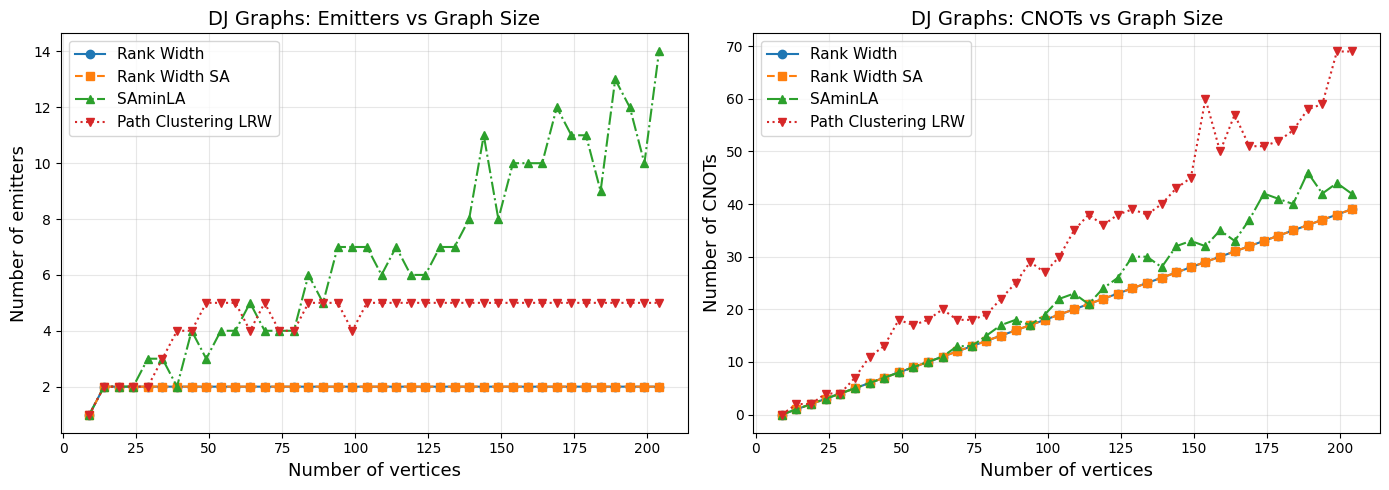

In [128]:
# --- Load and plot DJ graph results for all three methods ---
# Rank Width (exact)
dj_em_rw = load_simulation_results('dj_db_rank_width', 'emitters', db_name='dj_edu')
dj_cn_rw = load_simulation_results('dj_db_rank_width', 'cnots', db_name='dj_edu')
dj_ns_rw = load_simulation_results('dj_db_rank_width', 'node_sizes', db_name='dj_edu')

# Rank Width SA
dj_em_rwsa = load_simulation_results('dj_db_rank_width_sa', 'emitters', db_name='dj_edu')
dj_cn_rwsa = load_simulation_results('dj_db_rank_width_sa', 'cnots', db_name='dj_edu')

# SAminLA
dj_em_saminla = load_simulation_results('dj_db_saminla', 'emitters', db_name='dj_edu')
dj_cn_saminla = load_simulation_results('dj_db_saminla', 'cnots', db_name='dj_edu')

# path clustering linear rank width
dj_em_path = load_simulation_results('dj_db_path_clustering_lrw', 'emitters', db_name='dj_edu')
dj_cn_path = load_simulation_results('dj_db_path_clustering_lrw', 'cnots', db_name='dj_edu')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# --- Emitters plot ---
ax1.plot(dj_ns_rw, dj_em_rw, 'o-', color='tab:blue', markersize=6, linewidth=1.5, label='Rank Width')
ax1.plot(dj_ns_rw, dj_em_rwsa, 's--', color='tab:orange', markersize=6, linewidth=1.5, label='Rank Width SA')
ax1.plot(dj_ns_rw, dj_em_saminla, '^-.', color='tab:green', markersize=6, linewidth=1.5, label='SAminLA')
ax1.plot(dj_ns_rw, dj_em_path, 'v:', color='tab:red', markersize=6, linewidth=1.5, label='Path Clustering LRW')
ax1.set_xlabel('Number of vertices', fontsize=13)
ax1.set_ylabel('Number of emitters', fontsize=13)
ax1.set_title('DJ Graphs: Emitters vs Graph Size', fontsize=14)
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)

# --- CNOTs plot ---
ax2.plot(dj_ns_rw, dj_cn_rw, 'o-', color='tab:blue', markersize=6, linewidth=1.5, label='Rank Width')
ax2.plot(dj_ns_rw, dj_cn_rwsa, 's--', color='tab:orange', markersize=6, linewidth=1.5, label='Rank Width SA')
ax2.plot(dj_ns_rw, dj_cn_saminla, '^-.', color='tab:green', markersize=6, linewidth=1.5, label='SAminLA')
ax2.plot(dj_ns_rw, dj_cn_path, 'v:', color='tab:red', markersize=6, linewidth=1.5, label='Path Clustering LRW')
ax2.set_xlabel('Number of vertices', fontsize=13)
ax2.set_ylabel('Number of CNOTs', fontsize=13)
ax2.set_title('DJ Graphs: CNOTs vs Graph Size', fontsize=14)
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()